# Implementing a Graph Neural Network

### Import Libraries

In [1]:
import networkx as nx
import pandas as pd
import numpy as np
import itertools
import matplotlib.pylab as plt
%matplotlib inline
from sklearn.manifold import TSNE
import copy
import seaborn as sns
import torch
from torch.nn import Linear
import torch_geometric
from torch_geometric.nn import GCNConv
import torch.nn.functional as F
from torch_geometric.data import Data
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import classification_report, confusion_matrix

### Data Preprocessing for GCN Model

In [2]:
df = pd.read_csv('data/animal_dataset_processed.csv')

In [3]:
df.head()

,Animal,Height (cm),Weight (kg),Color,Lifespan (years),Diet,Habitat,Predators,Average Speed (km/h),Countries Found,Conservation Status,Family,Gestation Period (days),Social Structure,Offspring per Birth
0,Aardvark,117.5,52.5,Grey,25.0,Carnivore,"Savannas, Grasslands","Lions, Hyenas",40.0,Africa,Least Concern,Orycteropodidae,225.0,Solitary,1.0
1,Aardwolf,45.0,11.0,Yellow-brown,11.0,Carnivore,"Grasslands, Savannas","Lions, Leopards",27.0,Eastern and Southern Africa,Least Concern,Hyaenidae,90.0,Solitary,3.5
2,African Elephant,290.0,4350.0,Grey,65.0,Herbivore,"Savannas, Forests","Lions, Hyenas",25.0,Africa,Vulnerable,Elephantidae,650.0,Herd-based,1.0
3,African Lion,95.0,185.0,Tan,12.0,Carnivore,"Grasslands, Savannas","Hyenas, Crocodiles",58.0,Africa,Vulnerable,Felidae,101.5,Group-based,3.0
4,African Wild Dog,77.5,27.0,Multicolored,11.0,Carnivore,Savannas,"Lions, Hyenas",56.0,Sub-Saharan Africa,Endangered,Canidae,70.0,Group-based,11.0


The columns 'Predators', 'Color', and 'Habitat' contain duplicated values within rows, separated by commas.
As a result, we can't directly use the get_dummies method on these columns.
In this section, we handle the processing of these columns accordingly.\
For the other categorical columns, we simply use the get_dummies method.


In [4]:
columns = ['Predators', 'Color', 'Habitat']
columns_unique_values = {}
for col in columns:
    split_data = df[col].str.split(', ', expand=True).stack()

    unique_values = split_data.unique()
    columns_unique_values[col] = unique_values
    one_hot_df = pd.get_dummies(split_data).groupby(level=0).sum()
    one_hot_df = one_hot_df.reindex(columns=unique_values, fill_value=0)

    df = df.join(one_hot_df)

columns_unique_values['Family'] = [f'Family_{item}' for item in df['Family'].unique()]

df = df.drop(columns=['Habitat', 'Predators','Color'])

df = pd.get_dummies(data=df, columns=['Countries Found','Conservation Status', 'Family', 'Social Structure'])

In [5]:
df

,Animal,Height (cm),Weight (kg),Lifespan (years),Diet,Average Speed (km/h),Gestation Period (days),Offspring per Birth,Lions,Hyenas,...,Family_Vombatidae,Social Structure_Colony-based,Social Structure_Eusocial,Social Structure_Flocks,Social Structure_Group-based,Social Structure_Herd-based,Social Structure_Pack-based,Social Structure_Social groups,Social Structure_Social pods,Social Structure_Solitary
0,Aardvark,117.5,52.5,25.0,Carnivore,40.0,225.0,1.0,1,1,...,False,False,False,False,False,False,False,False,False,True
1,Aardwolf,45.0,11.0,11.0,Carnivore,27.0,90.0,3.5,1,0,...,False,False,False,False,False,False,False,False,False,True
2,African Elephant,290.0,4350.0,65.0,Herbivore,25.0,650.0,1.0,1,1,...,False,False,False,False,False,True,False,False,False,False
3,African Lion,95.0,185.0,12.0,Carnivore,58.0,101.5,3.0,0,1,...,False,False,False,False,True,False,False,False,False,False
4,African Wild Dog,77.5,27.0,11.0,Carnivore,56.0,70.0,11.0,1,1,...,False,False,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
182,Wombat,101.0,27.5,7.5,Herbivore,20.0,132.0,1.0,0,0,...,True,False,False,False,False,False,False,False,False,True
183,Yak,150.0,850.0,22.5,Herbivore,24.0,247.5,30.0,0,0,...,False,False,False,False,True,False,False,False,False,False
184,Yellow-Eyed Penguin,62.5,2.0,20.0,Carnivore,25.0,85.0,1.0,0,0,...,False,False,False,False,False,False,False,False,False,True
185,Zebra,280.0,650.0,22.5,Herbivore,25.0,272.5,12.5,1,1,...,False,False,False,False,True,False,False,False,False,False


Create a dictionary to map animal names to indices, and vice versa

In [6]:
animal_to_index = {animal: idx for idx, animal in enumerate(df['Animal'])}
index_to_animal = {idx: animal for animal, idx in animal_to_index.items()}

### Graph Implementation

We create a graph from the data where nodes represent animals and edges represent familial relationships.
An edge exists between two nodes if the corresponding animals belong to the same family.\
We believe this approach is optimal for addressing the problem, as an animal's diet often depends on its family.

In [7]:
nodes = list(df['Animal'].unique())
print("number of Edges: ", len(nodes))

number of Edges:  187


In [8]:
edges = []
for col in columns_unique_values['Family']:
    try:
        data = df[df[col] == 1]
        animals = data['Animal']
        permutation = list(itertools.combinations(animals, 2))
        edges.extend(permutation)
    except:
        print(col)
edges = list(set([tuple(sorted(e)) for e in edges]))

df = df.drop(columns=columns_unique_values['Family'])

print("number of Edges: ", len(edges))


number of Edges:  266


Now, we will create a graph using the generated nodes and edges, and then visualize it.

In [9]:
graph = nx.Graph()
graph.add_nodes_from(nodes)
graph.add_edges_from(edges)

Some nodes have no edges due to the uniqueness of certain animal families in our data.
Scientists have observed and classified around 1.2 million species of animals, but our sample contains only 200, resulting in some unique family structures not connecting to others.


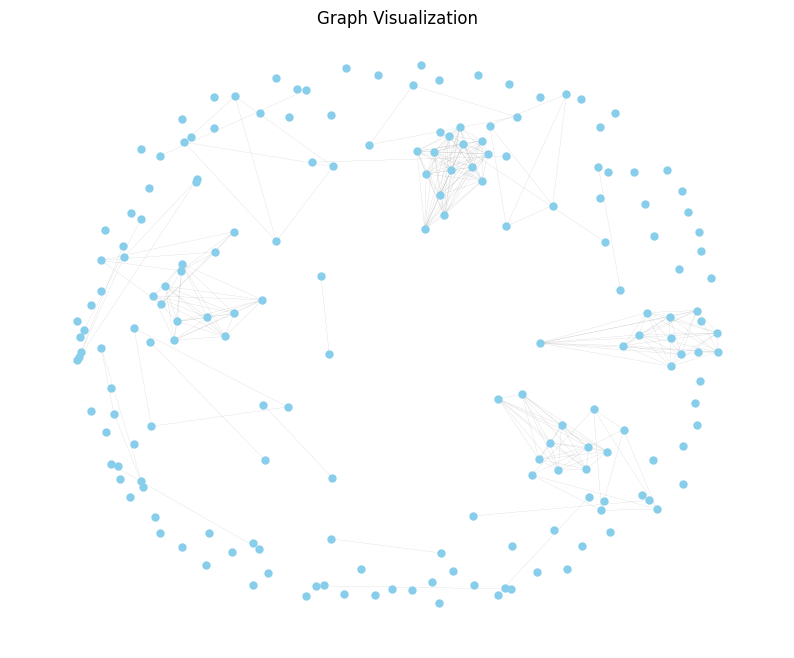

In [10]:
def visualize_graph(graph):
    pos = nx.spring_layout(graph, k=0.5)
    plt.figure(figsize=(10, 8))

    nx.draw_networkx_nodes(graph, pos, node_size=25, node_color='skyblue')
    nx.draw_networkx_edges(graph, pos, width=0.1, edge_color='gray', alpha=0.7)

    plt.title('Graph Visualization')
    plt.axis('off')

    plt.show()

visualize_graph(graph)

Convert animal names to indices for both nodes and edges

In [11]:
edges_index = [[animal_to_index[i] for i in e] for e in edges]
edges_index = torch.tensor(edges_index, dtype=torch.long).t().contiguous()

In [12]:
nodes_index = [animal_to_index[n] for n in nodes]
nodes_index = torch.tensor(nodes_index, dtype=torch.long)

Define node features and node targets

In [13]:
node_features = df.drop(columns=['Animal', 'Diet'])
node_targets = df['Diet']

Utilize label encoding for encoding node targets

In [14]:
label_encoder = LabelEncoder()
node_targets = label_encoder.fit_transform(node_targets)
node_targets = torch.tensor(node_targets, dtype=torch.long)

Create train, test, and validation masks for the model, as well as standard node features. Keeping the random state consistent ensures better comparability.

In [15]:
random_state = 42

np.random.shuffle(nodes_index)
train_mask, test_mask = train_test_split(nodes_index, test_size=0.1, random_state=random_state)

scaler = StandardScaler()
node_features = scaler.fit_transform(node_features)
node_features = torch.tensor(node_features, dtype=torch.float)

/tmp/ipykernel_614167/2434563350.py:3: UserWarning: you are shuffling a 'Tensor' object which is not a subclass of 'Sequence'; `shuffle` is not guaranteed to behave correctly. E.g., non-numpy array/tensor objects with view semantics may contain duplicates after shuffling.
  np.random.shuffle(nodes_index)


In [16]:
print('Node Features Shape: ', node_features.shape)
print('Node Targets Shape: ', node_targets.shape)

Node Features Shape:  torch.Size([187, 308])
Node Targets Shape:  torch.Size([187])


### Graph Convolutional Network (GCN) model architecture

Create Data object for Graph Convolutional Network (GCN) mode

In [17]:
num_nodes = len(nodes)

adj = torch_geometric.typing.SparseTensor( 
            row = edges_index[0].to(torch.int64), 
            col = edges_index[1].to(torch.int64), 
            sparse_sizes = (num_nodes, num_nodes), 
            is_sorted=True, 
            trust_data=True, 
        ) 
adj_t = adj.to_symmetric() 


data = Data(x=node_features, edge_index=edges_index, y=node_targets, adj_t=adj, train_mask=train_mask, test_mask=test_mask, num_classes=3)

Define the GCN (Graph Convolutional Network) model architecture.

In [18]:
class GCN(torch.nn.Module):
    def __init__(self, hidden_channels):
        super(GCN, self).__init__()
        torch.manual_seed(42)

        self.conv1 = GCNConv(data.num_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.out = Linear(hidden_channels, data.num_classes)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = F.dropout(x, p=0.5, training=self.training)

        x = self.conv2(x, edge_index)
        x = x.relu()
        x = F.dropout(x, p=0.5, training=self.training)

        x = self.out(x)
        return x
model = GCN(hidden_channels=32)
print(model)

GCN(
  (conv1): GCNConv(308, 32)
  (conv2): GCNConv(32, 32)
  (out): Linear(in_features=32, out_features=3, bias=True)
)


Visualize the model output embeddings using t-SNE before training the model.

In [19]:
def visualize(h, color):
    z = TSNE(n_components=2).fit_transform(h)
    color = label_encoder.inverse_transform(color)
    plt.figure(figsize=(10,10))
    sns.scatterplot(x=z[:, 0], y=z[:, 1], hue=color)
    plt.show()

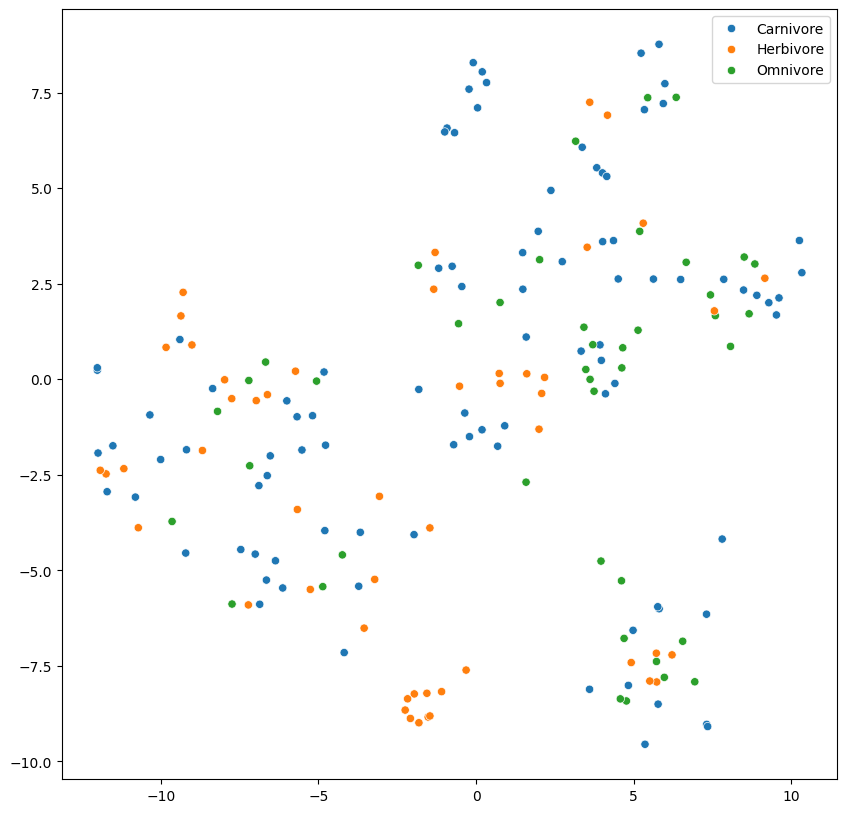

In [20]:
model = GCN(hidden_channels=16)
model.eval()

out = model(data.x, data.edge_index).cpu().detach().numpy()
visualize(out, color=data.y.cpu().numpy())

### Model Training

Define an early stopping object to prevent overfitting and determine the optimal stopping point for model training.

In [21]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0, restore_best_weights=True):
        self.patience = patience
        self.min_delta = min_delta
        self.restore_best_weights = restore_best_weights
        self.best_model = None
        self.best_loss = None
        self.counter = 0
        self.status = ""

    def __call__(self, model, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.best_model = copy.deepcopy(model.state_dict())
        elif self.best_loss - val_loss >= self.min_delta:
            self.best_model = copy.deepcopy(model.state_dict())
            self.best_loss = val_loss
            self.counter = 0
            self.status = f"Improvement found, counter reset to {self.counter}"
        else:
            self.counter += 1
            self.status = f"No improvement in the last {self.counter} epochs"
            if self.counter >= self.patience:
                self.status = f"Early stopping triggered after {self.counter} epochs."
                if self.restore_best_weights:
                    model.load_state_dict(self.best_model)
                return True
        return False

Training models using Adam optimizer with cross-entropy loss. Implementing 9-fold cross-validation on the dataset. If Cuda is available, training will be done on GPU.

In [22]:
def train(train_mask, val_mask):
      model.train()
      optimizer.zero_grad()
      out = model(data.x, data.edge_index)
      loss = criterion(out[data.train_mask], data.y[data.train_mask])
      loss.backward()
      optimizer.step()

      model.eval()
      out = model(data.x, data.edge_index)
      val_loss = criterion(out[data.val_mask], data.y[data.val_mask])

      return (loss, val_loss)

def test(train_mask, val_mask, test_mask):
      model.eval()
      out = model(data.x, data.edge_index)
      pred = out.argmax(dim=1)
      test_correct = pred[data.test_mask] == data.y[data.test_mask]
      test_acc = int(test_correct.sum()) / len(data.test_mask)

      train_correct = pred[data.train_mask] == data.y[data.train_mask]
      train_acc = int(train_correct.sum()) / len(data.train_mask)

      val_correct = pred[data.val_mask] == data.y[data.val_mask]
      val_acc = int(val_correct.sum()) / len(data.val_mask)
      return (test_acc, train_acc, val_acc)


train_losses = []
val_losses = []
accuracy = []

kfold = KFold(n_splits=9, shuffle=True, random_state=random_state)

for fold_idx, (train_index, val_index) in enumerate(kfold.split(train_mask)):

      model = GCN(hidden_channels=16)
      optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
      criterion = torch.nn.CrossEntropyLoss()

      device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
      model = model.to(device)

      train_index, val_index = torch.tensor(train_index, dtype=torch.long), torch.tensor(val_index, dtype=torch.long)
      data = Data(x=node_features, edge_index=edges_index, y=node_targets, adj_t= adj, train_mask=train_index, test_mask=test_mask, val_mask=val_index, num_classes=3).to(device)
      epochs = 100
      it = 0
      done = False
      es = EarlyStopping()
      train_loss = []
      val_loss = []
      best_val_acc = 0
      while not done and it < epochs:
            loss, val = train(train_index, val_index)
            train_loss.append(loss.item())
            val_loss.append(val.item())
            
            if es(model, val_loss[it]):
                        done = True
            it += 1
      _, val_acc, _ = test(train_index, val_index, test_mask)
      train_losses.append(np.mean(train_loss))
      val_losses.append(np.mean(val_loss))
      accuracy.append(val_acc)
      if val_acc > best_val_acc:
             best_val_acc = val_acc
             best_model = model
      print(f'Fold: {fold_idx}, Epoch: {it:03d}, Train Loss: {train_losses[fold_idx]:.4f}, Validation Loss: {val_losses[fold_idx]:.4f}')
model = best_model


Fold: 0, Epoch: 013, Train Loss: 0.9461, Validation Loss: 1.0205
Fold: 1, Epoch: 034, Train Loss: 0.7458, Validation Loss: 0.7776
Fold: 2, Epoch: 062, Train Loss: 0.6054, Validation Loss: 0.5298
Fold: 3, Epoch: 047, Train Loss: 0.6579, Validation Loss: 0.6793
Fold: 4, Epoch: 028, Train Loss: 0.7740, Validation Loss: 0.9588
Fold: 5, Epoch: 020, Train Loss: 0.8777, Validation Loss: 0.9234
Fold: 6, Epoch: 042, Train Loss: 0.6889, Validation Loss: 0.7247
Fold: 7, Epoch: 018, Train Loss: 0.9043, Validation Loss: 0.8809
Fold: 8, Epoch: 016, Train Loss: 0.8943, Validation Loss: 1.0216


### Model Evaluation

In this chart, we observe the model's validation and training loss per epoch.

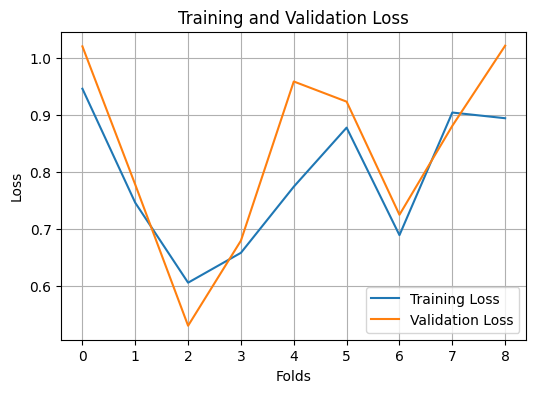

In [23]:
plt.figure(figsize=(6, 4))

plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Folds')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

Validation accuracy on Each Fold

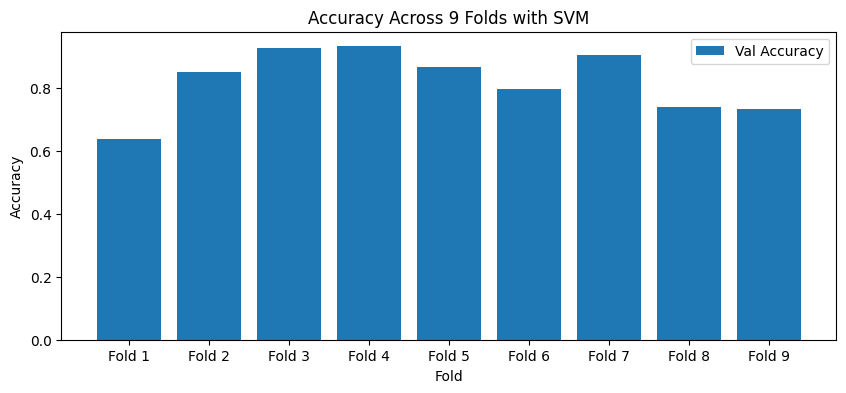

In [24]:
plt.figure(figsize=(10, 4))

labels = [f'Fold {i}' for i in range(1, 10)]
plt.bar(labels, accuracy, label='Val Accuracy')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('Accuracy Across 9 Folds with SVM')
plt.legend()
plt.show()

Model accuracy on the train and test sets.

In [25]:
test_acc, train_acc, val_acc = test(train_mask, test_mask, test_mask)
print(f'Test Accuracy: {test_acc:.4f}, Train Accuracy: {train_acc:.4f}')

Test Accuracy: 0.7895, Train Accuracy: 0.7333


Model evaluation on the test set

In [26]:
model.eval()
out = model(data.x, data.edge_index)
pred = out.argmax(dim=1)
y_pred = pred[data.test_mask].cpu().detach().numpy()
y_test = data.y[data.test_mask].cpu().detach().numpy()

print("Classification Report: ")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

Classification Report: 
              precision    recall  f1-score   support

   Carnivore       0.69      1.00      0.82         9
   Herbivore       1.00      0.67      0.80         6
    Omnivore       1.00      0.50      0.67         4

    accuracy                           0.79        19
   macro avg       0.90      0.72      0.76        19
weighted avg       0.85      0.79      0.78        19



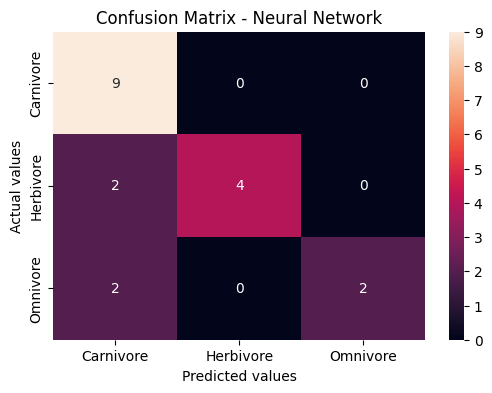

In [27]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - Neural Network')
plt.xlabel('Predicted values')
plt.ylabel('Actual values')
plt.show()

Now we observe the model embeddings post-training. The chart depicts well-defined clusters for each category, notably showing that 'Carnivore' and 'Herbivore' animals are closely aligned with the 'Omnivore' cluster, as expected.

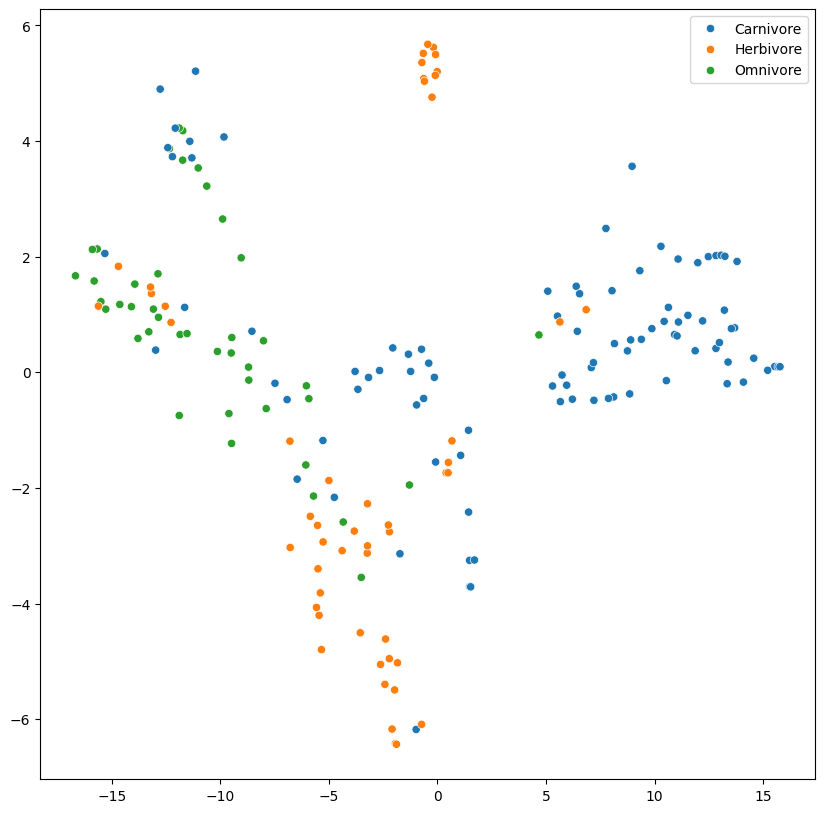

In [28]:
model.eval()

out = model(data.x, data.edge_index).detach().cpu().numpy()
visualize(out, color=data.y.cpu().detach().numpy())

### Final Comparison of accuracy among different machine learning algorithms on test data.

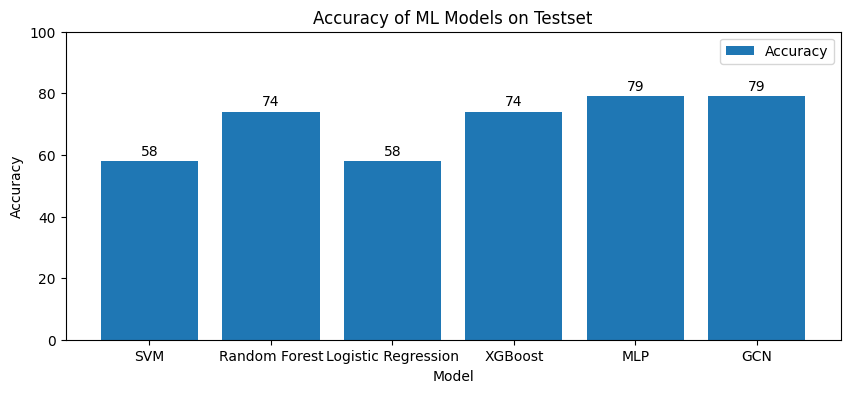

In [29]:
models_accuracy = {
    'SVM' : 58,
    'Random Forest' : 74,
    'Logistic Regression' : 58,
    'XGBoost' : 74,
    'MLP' : 79,
    'GCN' : 79
}

plt.figure(figsize=(10, 4))

labels = [f'Fold {i}' for i in range(1, 10)]
plt.bar(models_accuracy.keys(), models_accuracy.values(), label='Accuracy')
plt.ylim(0, 100)
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Accuracy of ML Models on Testset')

for i, value in enumerate(models_accuracy.values()):
    plt.text(i, value + 1, str(value), ha='center', va='bottom')

plt.legend()
plt.show()

Due to the presence of imbalanced datasets in the target variables, the macro average metric is a fairer evaluation measure.

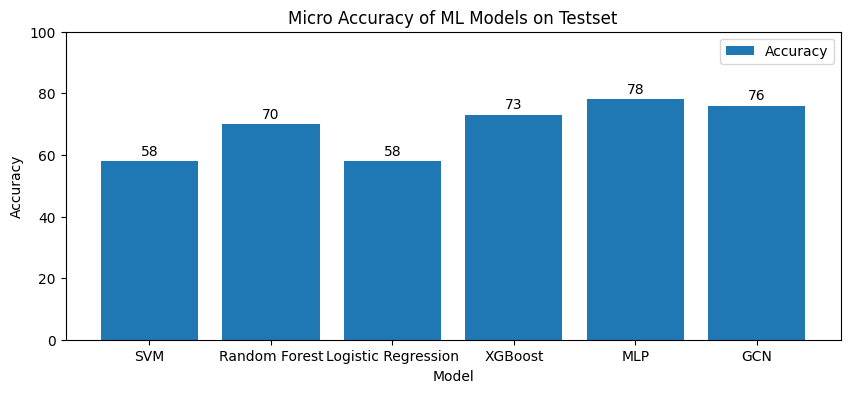

In [30]:
models_accuracy = {
    'SVM' : 58,
    'Random Forest' : 70,
    'Logistic Regression' : 58,
    'XGBoost' : 73,
    'MLP' : 78,
    'GCN' : 76
}

plt.figure(figsize=(10, 4))

labels = [f'Fold {i}' for i in range(1, 10)]
plt.bar(models_accuracy.keys(), models_accuracy.values(), label='Accuracy')
plt.ylim(0, 100)
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Micro Accuracy of ML Models on Testset')

for i, value in enumerate(models_accuracy.values()):
    plt.text(i, value + 1, str(value), ha='center', va='bottom')

plt.legend()
plt.show()